### CKD Stage Progression ###

We have two tables:
  * **ckd_enrollment**: Information about members
  * **ckd_claims**: Their claims (these include the combination of inpatient, outpatient and Rx claims)

The data spans the years 2017, 2018 and 2019.

In [1]:
# -----------------------------------------------------------------------------
# INITIALIZATION
# -----------------------------------------------------------------------------
import sys
print(f"Python version: {sys.version}")

import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np

import pyspark
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from functools import reduce

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  



Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/07/03 19:49:44 WARN Utils: Your hostname, Charles.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.153 instead (on interface en0)
25/07/03 19:49:44 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/07/03 19:49:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/07/03 19:49:45 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/07/03 19:49:45 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [3]:
# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

2025-07-03 19:49:46,415 INFO     >>> Reading enrollment file: /Users/Charles/DATA/ckd/ckd_enrollment
25/07/03 19:49:47 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-07-03 19:49:48,019 INFO     >>> ENROLLMENT has 2,586,930 rows
2025-07-03 19:49:49,381 INFO     >>> ENROLLMENT has 862,310 unique enrollees    
2025-07-03 19:49:49,383 INFO     >>> Reading claims file: /Users/Charles/DATA/ckd/ckd_claims
2025-07-03 19:49:50,172 INFO     >>> CLAIMS has 253,070,875 rows
2025-07-03 19:49:57,460 INFO     >>> CLAIMS has 862,310 unique enrollees        


In [4]:
example_enrolid = df_enrollment.select("ENROLID").limit(1).collect()[0]["ENROLID"]
print(f"Example ENROLID: {example_enrolid}")

# Filter the enrollment DataFrame for that ENROLID
df_enrollment.filter(F.col("ENROLID") == example_enrolid).show(truncate=False)


Example ENROLID: 1712066001


+----------+--------+-------+--------+-------+----+---+-----+------+------+-------+---+---+--------+------+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+--------+--------+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+--------+--------+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+--------+--------+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+--------+--------+-------+-------+-------+-------+--------+-----+------+--------+-------+-------+-------+-------+-------+-------+-------+-------+-------+--------+--------+--------+-----------+
|ENROLID   |SEQNUM  |VERSION|EFAMID  |MEMDAYS|YEAR|AGE|DOBYR|AGEGRP|EMPREL|PHYFLAG|RX |SEX|HLTHPLAN|ENRMON|DATTYP1|DATTYP2|DATTYP3|DATTYP4|DATTYP5|DATTYP6|DATTYP7|DATTYP8|DATTYP9|DATTYP10|DATTYP11|DATTYP12|ENRIND1|ENRIND2|ENRIND3|ENRIND4|ENRIND5|ENRIND6|ENRIND7|ENRIND8|ENRIND9|ENRIND10|ENRIND11|ENRIND12|MEMDAY1|MEMDAY2|M

### Build necessary dataframes + Functions

In [11]:

dx_cols = [col for col in df_claims.columns if col.__contains__("DX")]
# Step 2: Create CKD_STAGE using dynamic matching
def build_ckd_stage_case(dx_cols):
    stage_expr = None
    stage_map = {
        "N181": "CKD Stage 1",
        "N182": "CKD Stage 2",
        "N183": "CKD Stage 3",
        "N184": "CKD Stage 4",
        "N185": "CKD Stage 5",
        "N186": "ESRD",
        "N189": "Unspecified"
    }

    for code, label in stage_map.items():
        # Create a compound OR condition over all DX columns for each code
        condition = reduce(lambda a, b: a | b, [F.col(c).startswith(code) for c in dx_cols])
        if stage_expr is None:
            stage_expr = F.when(condition, label)
        else:
            stage_expr = stage_expr.when(condition, label)
    
    return stage_expr

# Step 3: Filter for CKD codes and extract stage
ckd_filter = reduce(lambda a, b: a | b, [F.col(c).startswith("N18") for c in dx_cols])

df_ckd_claims = (
    df_claims
    .filter(ckd_filter)
    .withColumn("CKD_STAGE", build_ckd_stage_case(dx_cols))
    .filter(F.col("CKD_STAGE").isNotNull())
    .filter(F.col("YEAR").isNotNull())
)


In [12]:

valid_stages = ["Unspecified","CKD Stage 1", "CKD Stage 2", "CKD Stage 3", "CKD Stage 4", "CKD Stage 5", "ESRD"]

df_ckd_yearly = (
    df_ckd_claims
    .filter(F.col("CKD_STAGE").isin(valid_stages))
    .filter(F.col("YEAR").isin([2017, 2018, 2019]))
    .select("ENROLID", "YEAR", "CKD_STAGE","STDPLAC")
    .dropDuplicates(["ENROLID", "YEAR", "CKD_STAGE"])
)
df_ckd_yearly.show()

+-----------+----+-----------+-------+
|    ENROLID|YEAR|  CKD_STAGE|STDPLAC|
+-----------+----+-----------+-------+
|  758145504|2019|Unspecified|     23|
| 4218293401|2019|CKD Stage 3|     21|
| 3057627602|2019|Unspecified|     21|
|  925851901|2019|Unspecified|     21|
|  976762502|2019|Unspecified|     21|
| 2844462001|2019|Unspecified|     23|
| 4015730401|2019|CKD Stage 3|     21|
| 1306552301|2018|       ESRD|     21|
|26286939901|2018|Unspecified|     21|
| 1902392302|2018|Unspecified|     21|
| 3544111102|2018|CKD Stage 3|     21|
| 2770522601|2018|Unspecified|     21|
|33245465201|2018|CKD Stage 5|     21|
| 1947336101|2018|CKD Stage 3|     21|
|32184740801|2018|CKD Stage 4|     21|
|32857082901|2018|       ESRD|     21|
| 3274745401|2018|CKD Stage 4|     21|
|32864503701|2018|Unspecified|     21|
|33042271201|2018|       ESRD|     21|
|33046097302|2018|       ESRD|     21|
+-----------+----+-----------+-------+
only showing top 20 rows


In [7]:
def compute_ckd_transition_matrices(df_ckd_yearly, years=[2017, 2018, 2019]):
    from pyspark.sql import functions as F

    df_ckd_pivot = (
        df_ckd_yearly
        .groupBy("ENROLID")
        .pivot("YEAR", years)
        .agg(F.first("CKD_STAGE"))
        .withColumnRenamed(str(years[0]), "stage_{}".format(years[0]))
        .withColumnRenamed(str(years[1]), "stage_{}".format(years[1]))
        .withColumnRenamed(str(years[2]), "stage_{}".format(years[2]))
        .filter(F.col(f"stage_{years[0]}").isNotNull() & F.col(f"stage_{years[1]}").isNotNull())
    )

    df_trans_1 = (
        df_ckd_pivot
        .groupBy(f"stage_{years[0]}", f"stage_{years[1]}")
        .agg(F.countDistinct("ENROLID").alias("count"))
        .toPandas()
    )

    df_pivot_2 = df_ckd_pivot.filter(F.col(f"stage_{years[2]}").isNotNull())

    df_trans_2 = (
        df_pivot_2
        .groupBy(f"stage_{years[1]}", f"stage_{years[2]}")
        .agg(F.countDistinct("ENROLID").alias("count"))
        .toPandas()
    )

    df_t1 = df_trans_1.pivot(index=f"stage_{years[0]}", columns=f"stage_{years[1]}", values="count").fillna(0)
    df_t2 = df_trans_2.pivot(index=f"stage_{years[1]}", columns=f"stage_{years[2]}", values="count").fillna(0)

    return df_t1, df_t2


In [8]:
def plot_ckd_transition_matrices(df_matrix, year_label="2017 → 2018"):
    import matplotlib.pyplot as plt
    import seaborn as sns

    df_row_norm = df_matrix.div(df_matrix.sum(axis=1), axis=0).fillna(0)
    df_col_norm = df_matrix.div(df_matrix.sum(axis=0), axis=1).fillna(0)

    plt.figure(figsize=(10, 6))
    sns.heatmap(df_col_norm, annot=True, cmap="Blues", fmt=".2f")
    plt.title(f"Column-Normalized CKD Stage Transition Matrix ({year_label})")
    plt.xlabel("To Stage")
    plt.ylabel("From Stage")
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.heatmap(df_row_norm, annot=True, cmap="Purples", fmt=".2f")
    plt.title(f"Row-Normalized CKD Stage Transition Matrix ({year_label})")
    plt.xlabel("To Stage")
    plt.ylabel("From Stage")
    plt.show()



### ✅ Check for Multiple Stages per Year
See how many patients have both Stage 3 and Stage 4 in a single year. Then redo transition matrix using most severe diagnosis per year

In [13]:

valid_stages = ["Unspecified","CKD Stage 1", "CKD Stage 2", "CKD Stage 3", "CKD Stage 4", "CKD Stage 5", "ESRD"]

df_ckd_yearly_stage_combos = (
    df_ckd_claims
    .filter(F.col("CKD_STAGE").isin(valid_stages))
    .groupBy("ENROLID", "YEAR")
    .agg(F.collect_set("CKD_STAGE").alias("stages"))
    .filter(F.size("stages") > 1)
)


In [14]:
df_ckd_yearly_counts_pd = df_ckd_yearly_stage_combos.toPandas()
display(df_ckd_yearly_counts_pd.head(2))
# Sort each stage list to normalize combinations
df_ckd_yearly_counts_pd["stage_combo"] = (
    df_ckd_yearly_counts_pd["stages"]
    .apply(lambda x: ", ".join(sorted(x)))
)

# Count frequency of each combination
stage_combo_counts = (
    df_ckd_yearly_counts_pd["stage_combo"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "Stage Combination", "stage_combo": "Count"})
)

display(df_ckd_yearly_counts_pd.head(2))


,ENROLID,YEAR,stages
0,602902,2019,"[CKD Stage 3, CKD Stage 4]"
1,26998101,2019,"[CKD Stage 3, CKD Stage 2]"


,ENROLID,YEAR,stages,stage_combo
0,602902,2019,"[CKD Stage 3, CKD Stage 4]","CKD Stage 3, CKD Stage 4"
1,26998101,2019,"[CKD Stage 3, CKD Stage 2]","CKD Stage 2, CKD Stage 3"


In [50]:

# Filter where both Stage 3 and Stage 4 are present
df_stage3_and_4 = df_ckd_yearly_stage_combos.filter(
    F.array_contains("stages", "CKD Stage 3") & F.array_contains("stages", "CKD Stage 4")
)

# Count enrollee-years
count_stage3_and_4 = df_stage3_and_4.count()
print(f"Number of enrollee-years with both Stage 3 and Stage 4: {count_stage3_and_4}")


Number of enrollee-years with both Stage 3 and Stage 4: 14922


## Regressors from Stage 4 to Stage 3

In [16]:
years = [2017, 2018, 2019]

df_ckd_pivot = (
    df_ckd_yearly
    .groupBy("ENROLID")
    .pivot("YEAR", years)
    .agg(F.first("CKD_STAGE"))
    .withColumnRenamed("2017", "stage_2017")
    .withColumnRenamed("2018", "stage_2018")
    .withColumnRenamed("2019", "stage_2019")
)
df_regressors = df_ckd_pivot.filter((F.col("stage_2017") == "CKD Stage 5") & (F.col("stage_2018") == "CKD Stage 4"))
df_regressors.show(5)


+----------+-----------+-----------+-----------+
|   ENROLID| stage_2017| stage_2018| stage_2019|
+----------+-----------+-----------+-----------+
| 159047802|CKD Stage 5|CKD Stage 4|CKD Stage 4|
| 223209102|CKD Stage 5|CKD Stage 4|CKD Stage 4|
|1583742901|CKD Stage 5|CKD Stage 4|Unspecified|
|2454153302|CKD Stage 5|CKD Stage 4|CKD Stage 4|
|2778829401|CKD Stage 5|CKD Stage 4|CKD Stage 5|
+----------+-----------+-----------+-----------+
only showing top 5 rows


In [ ]:
df_ckd_visits = df_ckd_yearly.join(df_regressors.select("ENROLID"), on="ENROLID", how="inner")
df_ckd_visits = df_ckd_visits.filter(F.col("YEAR").isin([2017, 2018]))
df_ckd_visits = df_ckd_visits.join(df_claims.select("ENROLID", "YEAR", "STDPLAC", "NETPAY"), 
                                   on=["ENROLID", "YEAR", "STDPLAC"], how="left")

df_summary = (
    df_ckd_visits
    .groupBy("YEAR", "STDPLAC")
    .agg(F.count("*").alias("n_claims"))
    .orderBy("YEAR", "n_claims", ascending=[True, False])
)
df_summary_pd = df_summary.toPandas()
import json
with open("stdplac_map.json", "r") as f:
    stdplac_group_map = json.load(f)

df_summary_pd["Location"] = (
    df_summary_pd["STDPLAC"].astype(str)
    .map(stdplac_group_map)
    .fillna("Unmapped")
)

fig = px.bar(
    df_summary_pd,
    x="Location",
    y="n_claims",
    color="YEAR",
    barmode="group",
    title="Visit Settings for Stage 5→4 Patients",
    labels={"n_claims": "Number of Claims"}
)
fig.show()

## "21": "Inpatient Hospital",    "22": "Outpatient Hospital-On Campus",
##  "11": "Office", 81 : Independent Laboratory
   

+----+-------+--------+
|YEAR|STDPLAC|n_claims|
+----+-------+--------+
|2017|21     |5518    |
|2017|11     |3746    |
|2017|22     |3554    |
|2017|81     |1759    |
|2017|65     |151     |
|2017|23     |105     |
|2017|12     |67      |
|2017|41     |2       |
|2017|19     |2       |
|2018|22     |4248    |
|2018|11     |3744    |
|2018|21     |2373    |
|2018|81     |1258    |
|2018|23     |102     |
|2018|12     |25      |
|2018|65     |16      |
|2018|50     |12      |
|2018|20     |10      |
|2018|99     |3       |
+----+-------+--------+



In [ ]:
df_regressors43 = df_ckd_pivot.filter((F.col("stage_2017") == "CKD Stage 4") & (F.col("stage_2018") == "CKD Stage 3"))
df_ckd_visits43 = df_ckd_yearly.join(df_regressors43.select("ENROLID"), on="ENROLID", how="inner")
df_ckd_visits43 = df_ckd_visits43.filter(F.col("YEAR").isin([2017, 2018]))
df_ckd_visits43 = df_ckd_visits43.join(df_claims.select("ENROLID", "YEAR", "STDPLAC", "NETPAY"), 
                                   on=["ENROLID", "YEAR", "STDPLAC"], how="left")

df_summary43 = (
    df_ckd_visits43
    .groupBy("YEAR", "STDPLAC")
    .agg(F.count("*").alias("n_claims"))
    .orderBy("YEAR", "n_claims", ascending=[True, False])
).toPandas()

df_summary43["Location"] = (
    df_summary43["STDPLAC"].astype(str)
    .map(stdplac_group_map)
    .fillna("Unmapped")
)

In [23]:
fig = px.bar(
    df_summary43,
    x="Location",
    y="n_claims",
    color="YEAR",
    barmode="group",
    title="Visit Settings for Stage 4→3 Patients",
    labels={"n_claims": "Number of Claims"}
)
fig.show()
   

## Plot yearly transition matrices 
including Unspecified

only count the most severe stage of the year per enrollee (see "check for multiple stages per enrollee per year", many patients have this!)

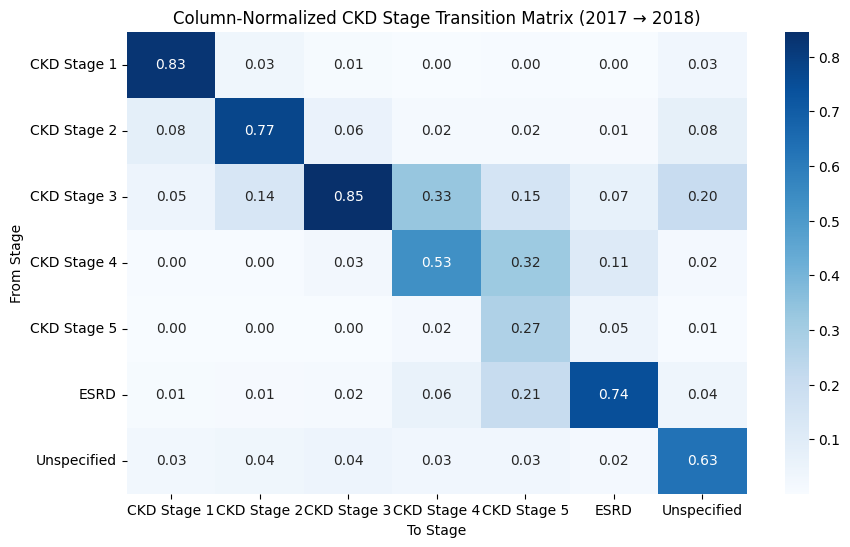

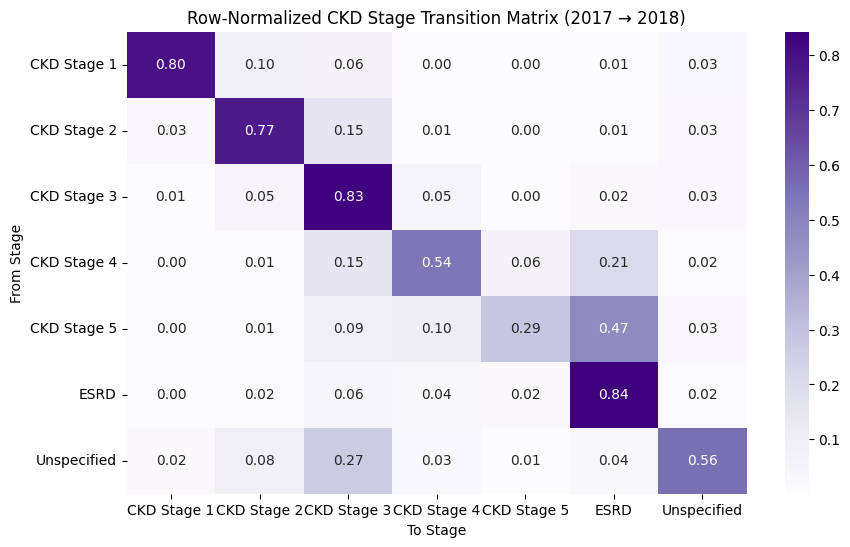

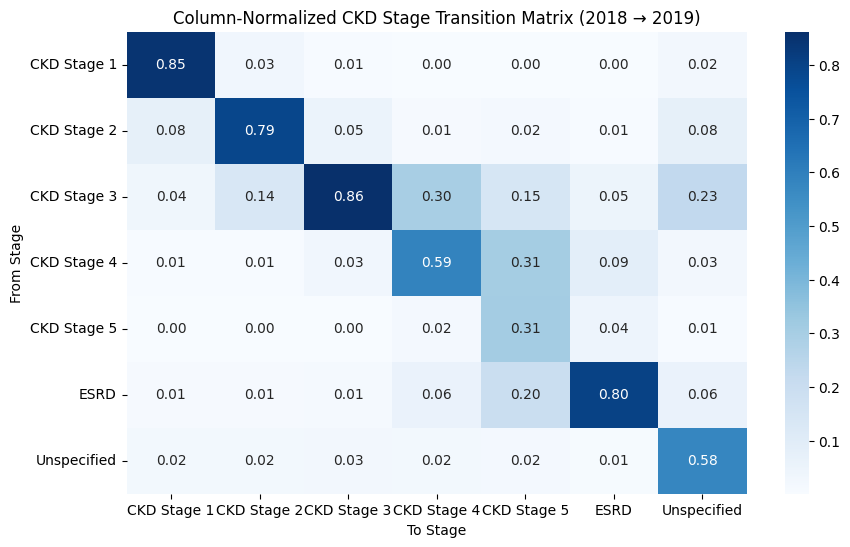

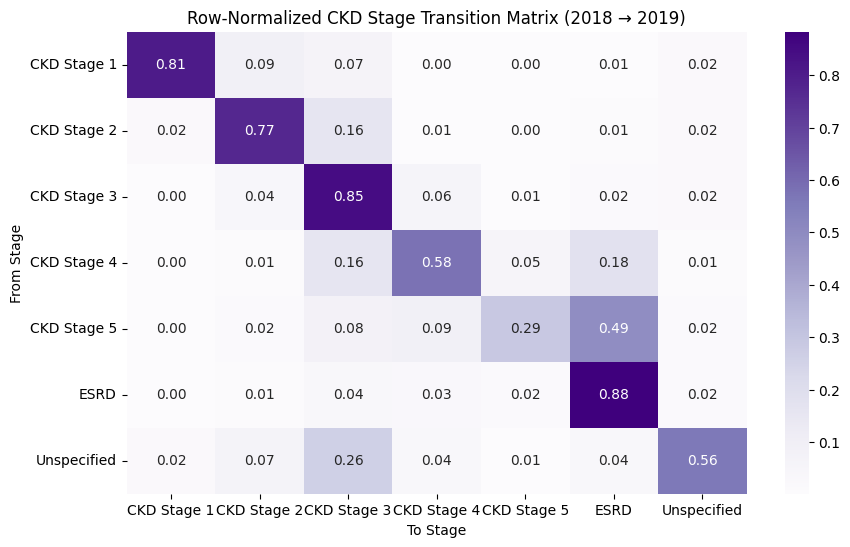

In [36]:
from pyspark.sql.window import Window

stage_order = {
    "CKD Stage 1": 1,
    "CKD Stage 2": 2,
    "CKD Stage 3": 3,
    "CKD Stage 4": 4,
    "CKD Stage 5": 5,
    "ESRD": 6,
    "Unspecified": 0
}
stage_order_expr = F.create_map([F.lit(kv) for kv in sum(stage_order.items(), ())])

df_ranked = (
    df_ckd_claims
    .withColumn("YEAR", F.year("SVCDATE"))
    .filter(F.col("CKD_STAGE").isNotNull())
    .withColumn("stage_rank", stage_order_expr[F.col("CKD_STAGE")])
)

window = Window.partitionBy("ENROLID", "YEAR").orderBy(F.desc("stage_rank"))

df_ckd_yearly_most_severe = (
    df_ranked
    .withColumn("rn", F.row_number().over(window))
    .filter("rn = 1")
    .select("ENROLID", "YEAR", "CKD_STAGE")
)
df_t1, df_t2 = compute_ckd_transition_matrices(df_ckd_yearly_most_severe)

plot_ckd_transition_matrices(df_t1, year_label="2017 → 2018")
plot_ckd_transition_matrices(df_t2, year_label="2018 → 2019")


### Matrix for 2017 to 2019 jump

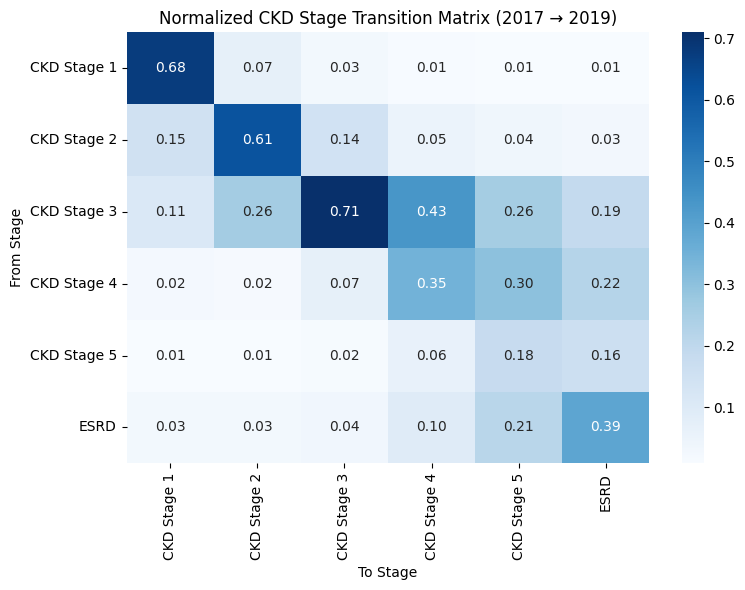

In [19]:

# First, filter CKD claims and keep only YEAR, ENROLID, and CKD_STAGE
df_ckd_year_stage = (
    df_ckd_claims
    .select("ENROLID", "YEAR", "CKD_STAGE")
    .distinct()
    .filter(F.col("YEAR").isin(2017, 2019))
)

# Create a window to select each enrollee’s stage in 2017 and 2019
df_stage_2017 = (
    df_ckd_year_stage
    .filter(F.col("YEAR") == 2017)
    .select(F.col("ENROLID"), F.col("CKD_STAGE").alias("stage_2017"))
)

df_stage_2019 = (
    df_ckd_year_stage
    .filter(F.col("YEAR") == 2019)
    .select(F.col("ENROLID"), F.col("CKD_STAGE").alias("stage_2019"))
)

# Join stages from 2017 and 2019
df_trans_17_19 = (
    df_stage_2017.join(df_stage_2019, on="ENROLID", how="inner")
    .groupBy("stage_2017", "stage_2019")
    .agg(F.count("*").alias("count"))
)


df_t3 = df_trans_17_19.toPandas().pivot(index="stage_2017", columns="stage_2019", values="count").fillna(0)

# Ensure all expected stages are present as rows and columns
df_t3 = df_t3.reindex(index=valid_stages, columns=valid_stages, fill_value=0)

# Normalize rows to get proportions
df_t3_normalized = df_t3.div(df_t3.sum(axis=1), axis=0)
df_t3_colnorm = df_t3.div(df_t3.sum(axis=0), axis=1)
# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(df_t3_colnorm, annot=True, fmt=".2f", cmap="Blues", cbar=True)
plt.title("Normalized CKD Stage Transition Matrix (2017 → 2019)")
plt.xlabel("To Stage")
plt.ylabel("From Stage")
plt.tight_layout()
plt.show()


### forward transitions (i.e. disease worsening)

In [13]:
from pyspark.sql import Window
from pyspark.sql.functions import row_number, lag, col, create_map, lit
import plotly.graph_objects as go
import pandas as pd

# Define CKD stage severity mapping
stage_order = {
    "CKD Stage 1": 1,
    "CKD Stage 2": 2,
    "CKD Stage 3": 3,
    "CKD Stage 4": 4,
    "CKD Stage 5": 5,
    "ESRD": 6
}

# Create PySpark map expression for stage ranking
stage_order_expr = create_map([lit(k) for pair in stage_order.items() for k in pair])

# Prepare CKD claims with stage rank
df_ckd_progression = (
    df_ckd_all
    .filter(col("CKD_STAGE").isin(list(stage_order.keys())))
    .select("ENROLID", "SVCDATE", "CKD_STAGE")
    .dropDuplicates(["ENROLID", "SVCDATE", "CKD_STAGE"])
    .withColumn("stage_rank", stage_order_expr[col("CKD_STAGE")])
)

# Compute transition window
w = Window.partitionBy("ENROLID").orderBy("SVCDATE")

df_trajectory = (
    df_ckd_progression
    .withColumn("prev_stage", lag("CKD_STAGE").over(w))
    .withColumn("prev_rank", lag("stage_rank").over(w))
)

# Filter only valid forward transitions (i.e. disease worsening)
df_transitions = (
    df_trajectory
    .filter(col("prev_stage").isNotNull())
    .filter(col("stage_rank") > col("prev_rank"))  # forward progression
    .groupBy("prev_stage", "CKD_STAGE")
    .count()
    .orderBy("count", ascending=False)
)

# Convert to Pandas
df_transitions_pd = df_transitions.toPandas()

# Sankey diagram
stages = pd.unique(df_transitions_pd[['prev_stage', 'CKD_STAGE']].values.ravel())
label_to_idx = {label: idx for idx, label in enumerate(stages)}

sources = df_transitions_pd['prev_stage'].map(label_to_idx)
targets = df_transitions_pd['CKD_STAGE'].map(label_to_idx)
values = df_transitions_pd['count']

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=list(stages),
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])

fig.update_layout(
    title_text="CKD Stage Progression (Forward Transitions Only)",
    font_size=14,
    width=1000,
    height=500
)

fig.show()


#### The distribution of how many patients saw year-over-year increases.

You can identify:

Patients with persistent cost growth (2–3 years increasing)

Stable or fluctuating cost patterns#

In [6]:
df_cost_trend = (
    df_claims
    .groupBy("ENROLID", "YEAR")
    .agg(F.sum("PAY").alias("yearly_cost"))
    .filter(F.col("yearly_cost") > 0)
)
df_cost_trend.show()

df_trend_pd = df_cost_trend.toPandas().pivot(index='ENROLID', columns='YEAR', values='yearly_cost')
df_trend_pd["n_increasing_years"] = (df_trend_pd.diff(axis=1) > 0).sum(axis=1)
import plotly.express as px

fig = px.histogram(
    df_trend_pd,
    x="n_increasing_years",
    title="Patients by Number of Years with Increasing Cost",
    labels={"n_increasing_years": "# Increasing Years"},
    nbins=4
)
fig.show()


+-----------+----+------------------+
|    ENROLID|YEAR|       yearly_cost|
+-----------+----+------------------+
|  711412502|2019| 51591.18000000001|
|  769057002|2019|161166.87999999998|
|  851536401|2019|13634.369999999999|
|  851767301|2019| 97445.29999999992|
| 3111902101|2019|26510.879999999994|
| 4219653901|2019|230989.23999999993|
| 4221069301|2019|48245.710000000014|
| 4222971401|2019| 80734.29000000004|
| 4225419701|2019| 40870.37999999999|
| 4226770701|2019|          49457.04|
| 4227828601|2019|45637.299999999996|
| 4228408801|2019|18828.140000000003|
|27104853502|2019| 169778.6899999999|
| 3059554202|2019| 53179.06999999999|
|  900927701|2019|39826.030000000006|
|  902681402|2019| 60340.32000000001|
|  929041901|2019|          22294.85|
|  961353901|2019| 97496.72000000003|
| 2845695901|2019| 55217.02000000001|
| 2849030002|2019|          20290.29|
+-----------+----+------------------+
only showing top 20 rows


## AVERAGE COST PER ENROLLEE PER YEAR (OMID)

In [6]:
%%spark_sql
-- CALCULATE THE SAME AS ABOVE (AVERAGE COST PER ENROLLEE PER YEAR)
-- BUT USING SQL INSTEAD OF PYSPARK
--
-- Use the "%%spark_sql" magic in the first line of cell to run SQL queries.
-- Remember: you must first use the "createOrReplaceTempView" method (called earlier)
-- to define a view of the tables you want to use, for example:
--     df_enrollment.createOrReplaceTempView('enrollment')

-- First define two auxiliary queries:
--     "total_cost": total cost per year
--     "n_persons": number of enrollees per year
WITH
    total_cost_view AS (
        SELECT YEAR, SUM(PAY) AS total_cost
        FROM claims
        GROUP BY YEAR
        ORDER BY YEAR
    ),
    n_persons_view AS (
        SELECT YEAR, COUNT(*) AS n_persons
        FROM enrollment
        GROUP BY YEAR
        ORDER BY YEAR
    )

-- Now run the main query:
SELECT 
    total_cost_view.YEAR, 
    total_cost_view.total_cost/n_persons_view.n_persons AS avg_cost
FROM total_cost_view, n_persons_view
WHERE total_cost_view.YEAR = n_persons_view.YEAR
ORDER BY total_cost_view.YEAR;


+----+-----------------+
|YEAR|         avg_cost|
+----+-----------------+
|2017|18938.65895937602|
|2018|23164.19680476903|
|2019|24726.71270882901|
+----+-----------------+



In [7]:
# -- THIRD ALTERNATIVE: COMBINE PYSPARK AND SQL

# -- Using "%%spark_sql" magic to run SQL queries is a good way to
# -- quickly explore the data. But often you want to use pyspark,
# -- for example to save the results of a query to a parquet file.
# -- or create a pandas dataframe out of it.
# --
# -- You can still use SQL queries instead of "pure" pyspark and
# -- get the result as a pyspark dataframe:
query = """
WITH
    total_cost_view AS (
        SELECT YEAR, SUM(PAY) AS total_cost
        FROM claims
        GROUP BY YEAR
        ORDER BY YEAR
    ),
    n_persons_view AS (
        SELECT YEAR, COUNT(*) AS n_persons
        FROM enrollment
        GROUP BY YEAR
        ORDER BY YEAR
    )

SELECT 
    total_cost_view.YEAR, 
    total_cost_view.total_cost/n_persons_view.n_persons AS avg_cost
FROM total_cost_view, n_persons_view
WHERE total_cost_view.YEAR = n_persons_view.YEAR
ORDER BY total_cost_view.YEAR;
"""
df_avg_cost = spark.sql(query)
df_avg_cost.show()

# -- Convert to pandas dataframe and save as csv
df_avg_cost_pandas = df_avg_cost.toPandas()
df_avg_cost_pandas.to_csv("ckd_example_avg_cost.csv", index=False, header=True)

+----+-----------------+
|YEAR|         avg_cost|
+----+-----------------+
|2017|18938.65895937602|
|2018|23164.19680476903|
|2019|24726.71270882901|
+----+-----------------+



In [8]:
# SAVING THE RESULTS OF A QUERY TO A PARQUET FILE

# -- We have the "df" pyspark dataframe and we want to save it into
# -- our file system. The best way is to save it as a parquet file:
parquet_file = "ckd_example_avg_cost.parquet"
df_avg_cost.write.format("parquet").mode("overwrite").save(parquet_file)
logger.info(f">>> Saved {df_avg_cost.count():,} rows to {parquet_file}")

# -- We can read it back into a pyspark dataframe:
df = spark.read.format("parquet").load(parquet_file)
df.show()



2025-06-23 14:10:09,857 INFO     >>> Saved 3 rows to ckd_example_avg_cost.parquet


+----+-----------------+
|YEAR|         avg_cost|
+----+-----------------+
|2017|18938.65895937602|
|2018|23164.19680476903|
|2019|24726.71270882901|
+----+-----------------+



In [9]:
# CONVERT A PYSPARK DATAFRAME INTO A PANDAS DATAFRAME AND SAVE AS CSV

# -- Saving data in parquet files has the advantage that the data
# -- is stored in a binary format that is more efficient to read and
# -- write. The parquet file also keeps information about the data type
# -- of each column (e.g. integer, string etc).
# -- It can also handle very large datasets.
# --
# -- However, in some cases, if the dataframe is not too large, you
# -- want to either use pandas to do some calculations and/or save
# -- the data in CSV format so that it can be read from other programs

df_pandas = df_avg_cost.toPandas()
csv_file = "ckd_example_avg_cost.csv"
df_pandas.to_csv(csv_file, index=False, header=True)
logger.info(f">>> Saved {df_pandas.shape[0]:,} rows to {csv_file}")

# -- We can read it back into a pyspark dataframe:
df = spark.read.format("csv").option("header", "true").load(csv_file)
df.show()




2025-06-23 14:10:09,964 INFO     >>> Saved 3 rows to ckd_example_avg_cost.csv


+----+-----------------+
|YEAR|         avg_cost|
+----+-----------------+
|2017|18938.65895937602|
|2018|23164.19680476903|
|2019|24726.71270882901|
+----+-----------------+



In [10]:
# -- NOTE: you can read the CSV file back, but as CSV files do not
# -- keep data type information, you will need to convert the columns
# -- to the correct data type.
df2 = spark.read.format("csv").option("header", "true").load("ckd_example_avg_cost.csv")
df2.show()

# -- However the data types are not correct:
print(">>> Read dataframe data types:")
for x in df2.schema:
    print(f">>>     Column: '{x.name}' has data type '{x.dataType}'")



+----+-----------------+
|YEAR|         avg_cost|
+----+-----------------+
|2017|18938.65895937602|
|2018|23164.19680476903|
|2019|24726.71270882901|
+----+-----------------+

>>> Read dataframe data types:
>>>     Column: 'YEAR' has data type 'StringType()'
>>>     Column: 'avg_cost' has data type 'StringType()'


In [11]:
# -- So, when reading CSV files to parquet, you need to specify the correct
# -- data types for each column.

schema = T.StructType([
    T.StructField("YEAR", T.IntegerType(), True),
    T.StructField("avg_cost", T.DoubleType(), True)
])
df2 = spark.read.format("csv").option("header", "true").schema(schema).load("ckd_example_avg_cost.csv")
df2.show()

# -- Now the data types are correct:
for x in df2.schema:
    print(f">>> Column: '{x.name}' has data type '{x.dataType}'")

+----+-----------------+
|YEAR|         avg_cost|
+----+-----------------+
|2017|18938.65895937602|
|2018|23164.19680476903|
|2019|24726.71270882901|
+----+-----------------+

>>> Column: 'YEAR' has data type 'IntegerType()'
>>> Column: 'avg_cost' has data type 'DoubleType()'


In [12]:
# PLOT RESULTS
# -- Plot the average cost per enrollee per year
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()

# -- "plotly" uses pandas dataframes
df_avg_cost_pandas = df_avg_cost.toPandas().sort_values(by="YEAR")
 
fig.add_trace(go.Scatter(
    x=df_avg_cost_pandas["YEAR"],
    y=df_avg_cost_pandas["avg_cost"],
    mode="lines+markers",
    name="Average cost",
    line=dict(color="blue", dash="solid", width=3)
))

fig.update_layout(
    title=dict (
        text="AVERAGE COST PER ENROLLEE PER YEAR",
        font=dict(size=16, weight="bold")
    ),
    width=800,
    height=600,
    xaxis = dict(
        title=dict(
            text="Year",
            font=dict(size=16, weight="bold"),
        ),
        tickfont=dict(size=14, weight="bold"),
        tickformat="d",
    ),
    yaxis = dict(
        title=dict(
            text="Cost ($)",
            font=dict(size=16, weight="bold"),
        ),
        tickfont=dict(size=14, weight="bold"),
        tickformat=",d",
    ),
    legend = dict(
        font=dict(size=16, weight="bold"),
    ),
    xaxis_title_font=dict(size=16, weight="bold"),
    yaxis_title_font=dict(size=16, weight="bold"),
    legend_font=dict(size=16, weight="bold"),
    showlegend=True,
)

fig.show()
